**Źródło danych meteorologicznych: Open-Meteo Historical Forecast API**

**Model:** ECMWF IFS HRES
- Globalny model numeryczny, najwyższa rozdzielczość spośród globalnych systemów (9 km, 137 warstw pionowych)
- Uruchamiany co 6h (00, 06, 12, 18 UTC), prognoza do 10 dni
- Inicjalizowany danymi ze stacji, satelitów, radarów, samolotów, sondaży, boi
- Archiwum na Open-Meteo od 2017-01-01

**Jak działa Historical Forecast API:**
- Składa pierwsze godziny każdej aktualizacji modelu → spójny szereg czasowy
- Każda godzina ma prognozę o najkrótszym horyzoncie (0–6h) = najdokładniejsza
- Dla Europy Środkowej różnica vs lokalne stacje pomiarowe jest minimalna

**Dane dla pracy:**
- Zakres: 2020-01-01 - 2026-04-18, 2301 dni
- Punkt: 51.1155°N, 17.0283°E (stacja Korzeniowskiego)
- 25 zmiennych: temperatura, wilgotność, punkt rosy, wiatr (speed/gust/direction), ciśnienie (MSL + surface), opady (total/rain/snow), nasłonecznienie, sunshine duration, zachmurzenie (total + low), BLH, ewapotranspiracja
- Pokrycie 10/10 zmiennych z Czernecki et al. (2021) Table 2

**Dokładność:**
- Temperatura 2m: RMSE 1–2°C na 24h prognozy
- Opady: niższa dokładność (jak w każdym modelu)
- BLH: zmienna modelowana, nie mierzona — zależy od parametryzacji konwekcji

**Ograniczenia:**
- 9 km nie odwzorowuje efektów mikroklimatycznych miasta
- Model ewoluuje (cykle IFS aktualizowane co rok) -niejednorodność w szeregu

Zippenfenig, P. (2023). Open-Meteo.com Weather API. Zenodo. https://doi.org/10.5281/ZENODO.7970649


In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import dtale
from ydata_profiling import ProfileReport
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pingouin as pg
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_style('darkgrid')

In [39]:
def vif_res(df, vars):
    X = df[vars]
    X_with_const = add_constant(X)   

    vif = pd.DataFrame({
        'variable': X_with_const.columns,
        'VIF': [variance_inflation_factor(X_with_const.values, i) 
                for i in range(X_with_const.shape[1])]
    })

    vif = vif[vif['variable'] != 'const'].sort_values('VIF', ascending=False)
    return vif

In [40]:
df = pd.read_csv("./data/eda_data/openmeteo_wroclaw_forecast_daily.csv")
df

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,windspeed_10m_max,windspeed_10m_mean,windgusts_10m_max,...,et0_fao_evapotranspiration,blh_mean,blh_min,blh_max,dewpoint_2m_mean,dewpoint_2m_min,dewpoint_2m_max,cloudcover_low_mean,windspeed_10m_min,surface_pressure_mean
0,2020-01-01,4.3,-1.8,2.2,93,76,87,18.9,14.3,37.1,...,0.35,NaN,NaN,NaN,0.18,-2.8,1.7,33.08,6.9,1018.65
1,2020-01-02,5.8,-4.6,-1.4,92,39,67,14.6,8.1,20.9,...,0.58,NaN,NaN,NaN,-7.11,-9.2,-3.8,0.17,2.9,1014.42
2,2020-01-03,4.7,-4.2,0.4,88,62,79,22.9,14.4,41.8,...,0.53,NaN,NaN,NaN,-2.93,-7.6,1.0,35.75,8.4,1007.77
3,2020-01-04,6.2,2.0,4.0,93,79,86,32.9,25.2,69.1,...,0.48,NaN,NaN,NaN,1.92,-0.4,4.4,76.75,16.9,1004.14
4,2020-01-05,3.0,-3.7,0.1,93,70,83,27.6,18.0,60.5,...,0.53,NaN,NaN,NaN,-2.40,-4.6,-1.0,9.12,7.6,1016.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2277,2026-03-27,8.9,1.0,5.0,92,35,60,16.9,13.3,40.3,...,2.20,778.96,280.0,1610.0,-2.82,-6.1,0.0,24.46,9.7,1004.62
2278,2026-03-28,7.8,1.3,4.5,92,44,63,13.3,9.9,29.5,...,1.52,414.58,165.0,835.0,-2.12,-4.0,3.2,50.25,5.6,1004.80
2279,2026-03-29,7.9,3.0,5.3,97,66,83,19.0,13.2,42.1,...,0.90,529.58,115.0,1065.0,2.53,1.9,3.2,91.54,6.7,1007.74
2280,2026-03-30,9.0,0.9,5.4,91,52,70,14.9,9.9,35.6,...,1.66,535.62,45.0,1390.0,-0.03,-1.4,2.4,27.29,4.2,1001.33


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2282 entries, 0 to 2281
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        2282 non-null   object 
 1   temperature_2m_max          2282 non-null   float64
 2   temperature_2m_min          2282 non-null   float64
 3   temperature_2m_mean         2282 non-null   float64
 4   relative_humidity_2m_max    2282 non-null   int64  
 5   relative_humidity_2m_min    2282 non-null   int64  
 6   relative_humidity_2m_mean   2282 non-null   int64  
 7   windspeed_10m_max           2282 non-null   float64
 8   windspeed_10m_mean          2282 non-null   float64
 9   windgusts_10m_max           2282 non-null   float64
 10  winddirection_10m_dominant  2282 non-null   int64  
 11  pressure_msl_mean           2282 non-null   float64
 12  precipitation_sum           2282 non-null   float64
 13  rain_sum                    2282 

In [42]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

date                             0
temperature_2m_max               0
temperature_2m_min               0
temperature_2m_mean              0
relative_humidity_2m_max         0
relative_humidity_2m_min         0
relative_humidity_2m_mean        0
windspeed_10m_max                0
windspeed_10m_mean               0
windgusts_10m_max                0
winddirection_10m_dominant       0
pressure_msl_mean                0
precipitation_sum                0
rain_sum                         0
snowfall_sum                     0
shortwave_radiation_sum          0
sunshine_duration                0
cloudcover_mean                  0
et0_fao_evapotranspiration       0
blh_mean                      1724
blh_min                       1724
blh_max                       1724
dewpoint_2m_mean                 0
dewpoint_2m_min                  0
dewpoint_2m_max                  0
cloudcover_low_mean              0
windspeed_10m_min                0
surface_pressure_mean            0
dtype: int64

Total:

Przyczyna braków: boundary_layer_height nie jest archiwizowane w modelu ecmwf_ifs dla lat 2020–2023 — Open-Meteo przechowuje je tam dopiero od ~2024.

In [43]:
df = df.drop(columns=['blh_mean', 'blh_min', 'blh_max'])

In [44]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

date                          0
temperature_2m_max            0
temperature_2m_min            0
temperature_2m_mean           0
relative_humidity_2m_max      0
relative_humidity_2m_min      0
relative_humidity_2m_mean     0
windspeed_10m_max             0
windspeed_10m_mean            0
windgusts_10m_max             0
winddirection_10m_dominant    0
pressure_msl_mean             0
precipitation_sum             0
rain_sum                      0
snowfall_sum                  0
shortwave_radiation_sum       0
sunshine_duration             0
cloudcover_mean               0
et0_fao_evapotranspiration    0
dewpoint_2m_mean              0
dewpoint_2m_min               0
dewpoint_2m_max               0
cloudcover_low_mean           0
windspeed_10m_min             0
surface_pressure_mean         0
dtype: int64

Total: 0


In [45]:
df[df.duplicated()] # brak duplikatow dat

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,windspeed_10m_max,windspeed_10m_mean,windgusts_10m_max,...,shortwave_radiation_sum,sunshine_duration,cloudcover_mean,et0_fao_evapotranspiration,dewpoint_2m_mean,dewpoint_2m_min,dewpoint_2m_max,cloudcover_low_mean,windspeed_10m_min,surface_pressure_mean


In [46]:
df["date"] = pd.to_datetime(df["date"])

In [47]:
# profile = ProfileReport(
#     df,
#     tsmode=True,
#     sortby="date",
#     vars={"timeseries": {"pacf_acf_lag": 365, "significance_threshold": 0.05}}
# )

# profile.to_file("./auto_report/ydata-profiling_timeseries_report_openmeteo.html")

In [48]:
df = df.set_index('date')

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m_max,2282.0,14.487292,8.681304,-8.00,7.4000,14.400,21.7000,36.70
temperature_2m_min,2282.0,6.392244,7.101618,-18.00,0.8000,6.000,12.6000,22.00
temperature_2m_mean,2282.0,10.383041,7.761001,-11.00,4.2000,10.000,17.3000,29.10
relative_humidity_2m_max,2282.0,89.986854,7.989845,47.00,87.0000,92.000,95.0000,100.00
relative_humidity_2m_min,2282.0,56.972831,15.922135,20.00,44.0000,56.000,69.0000,97.00
relative_humidity_2m_mean,2282.0,74.776512,11.759351,35.00,67.0000,76.000,84.0000,99.00
windspeed_10m_max,2282.0,17.941411,6.696743,4.50,13.2000,16.800,21.6000,52.30
windspeed_10m_mean,2282.0,11.774759,4.939400,2.20,8.3000,10.900,14.4000,39.20
windgusts_10m_max,2282.0,35.546144,12.602137,9.70,26.6000,33.800,42.1000,101.90
winddirection_10m_dominant,2282.0,209.425066,88.791259,0.00,137.5000,229.000,283.0000,360.00


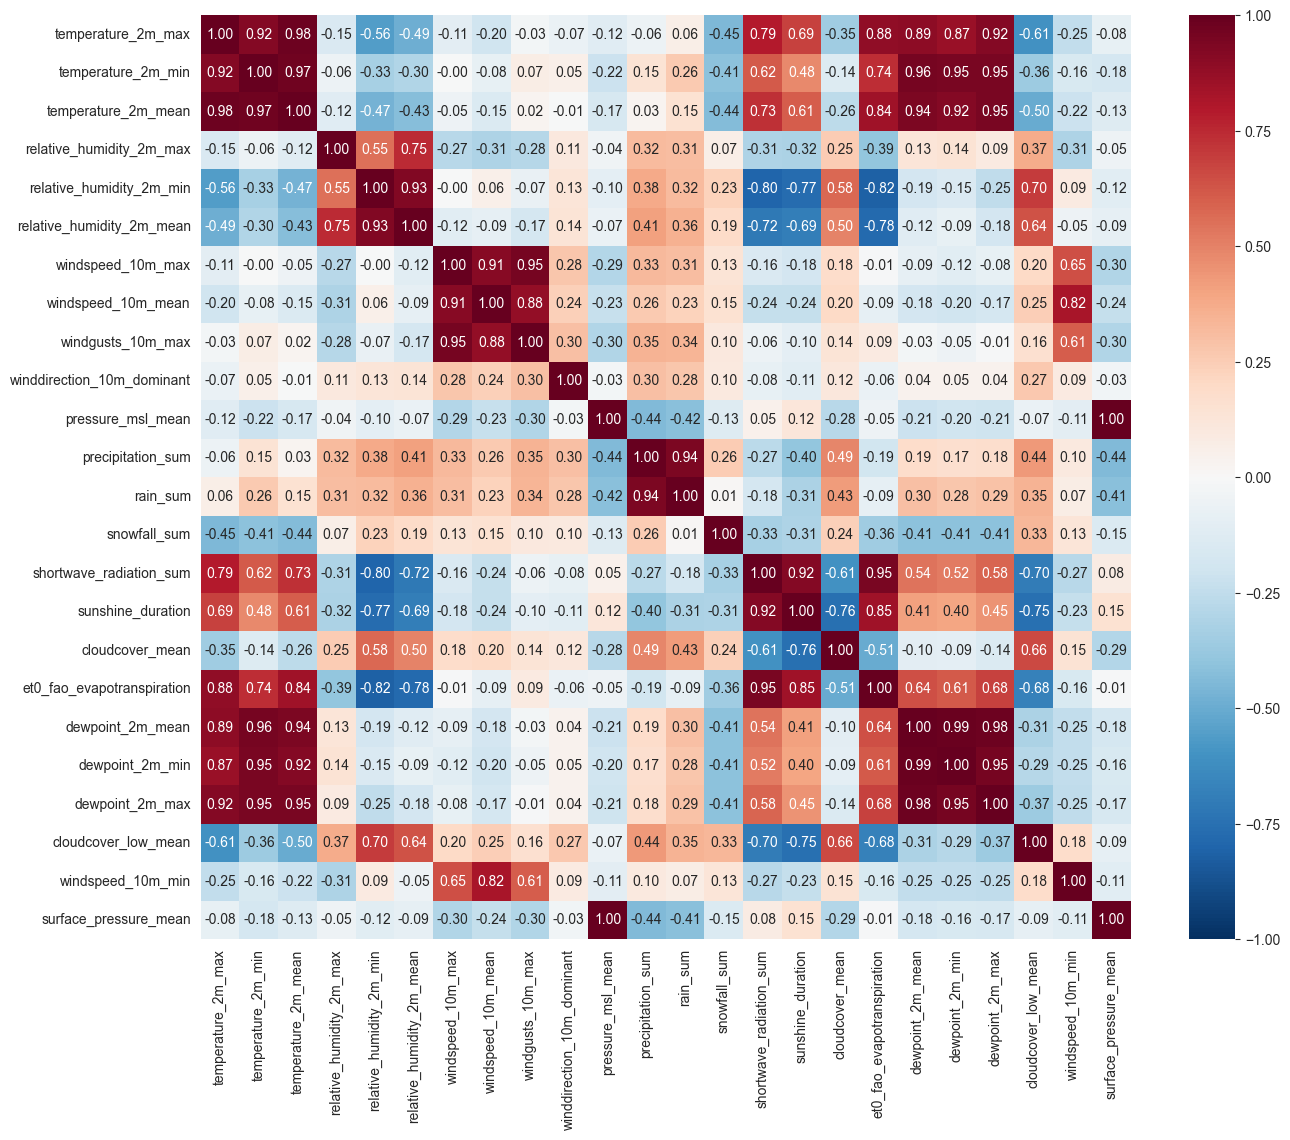

In [50]:
# corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 1, figsize=(15, 12))
# sns.heatmap(corr_pearson, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[0], fmt='.2f')
sns.heatmap(corr_spearman, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes, fmt='.2f')
plt.show()

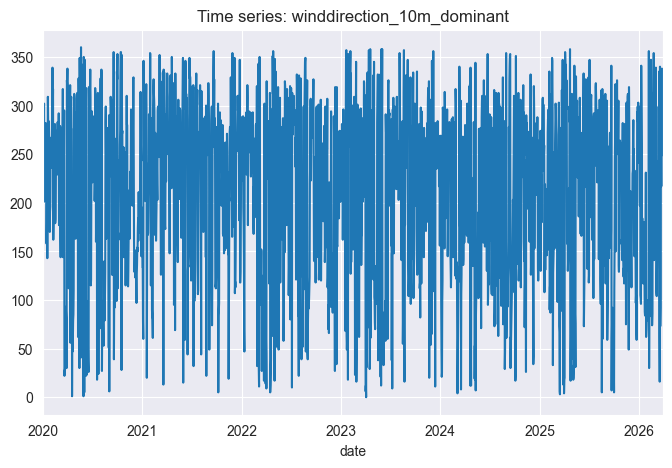

In [51]:
df['winddirection_10m_dominant'].plot(title=f'Time series: winddirection_10m_dominant', figsize=(8,5))
plt.show() # KąT!!!!

In [52]:
df['wind_u'] = df['windspeed_10m_mean'] * np.sin(np.deg2rad(df['winddirection_10m_dominant']))
df['wind_v'] = df['windspeed_10m_mean'] * np.cos(np.deg2rad(df['winddirection_10m_dominant']))

# winddirection_10m_dominant to zmienna kątowa (0–360°). Nie wolno jej wrzucić do modelu jako liczby, bo 350° i 10° są blisko siebie fizycznie, a daleko numerycznie!  
# podobnie zrobili w Kaya & Bucak (2025) ale tam ustalili sztywno

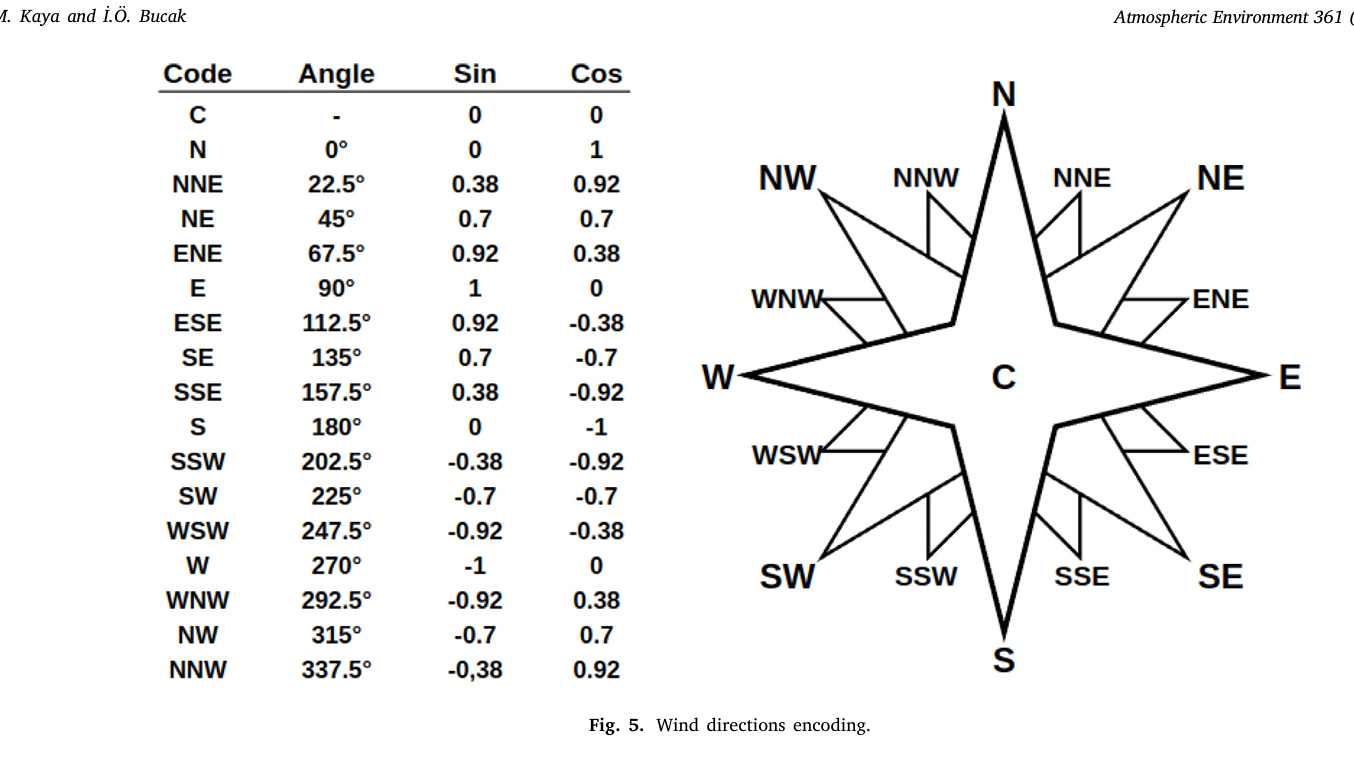

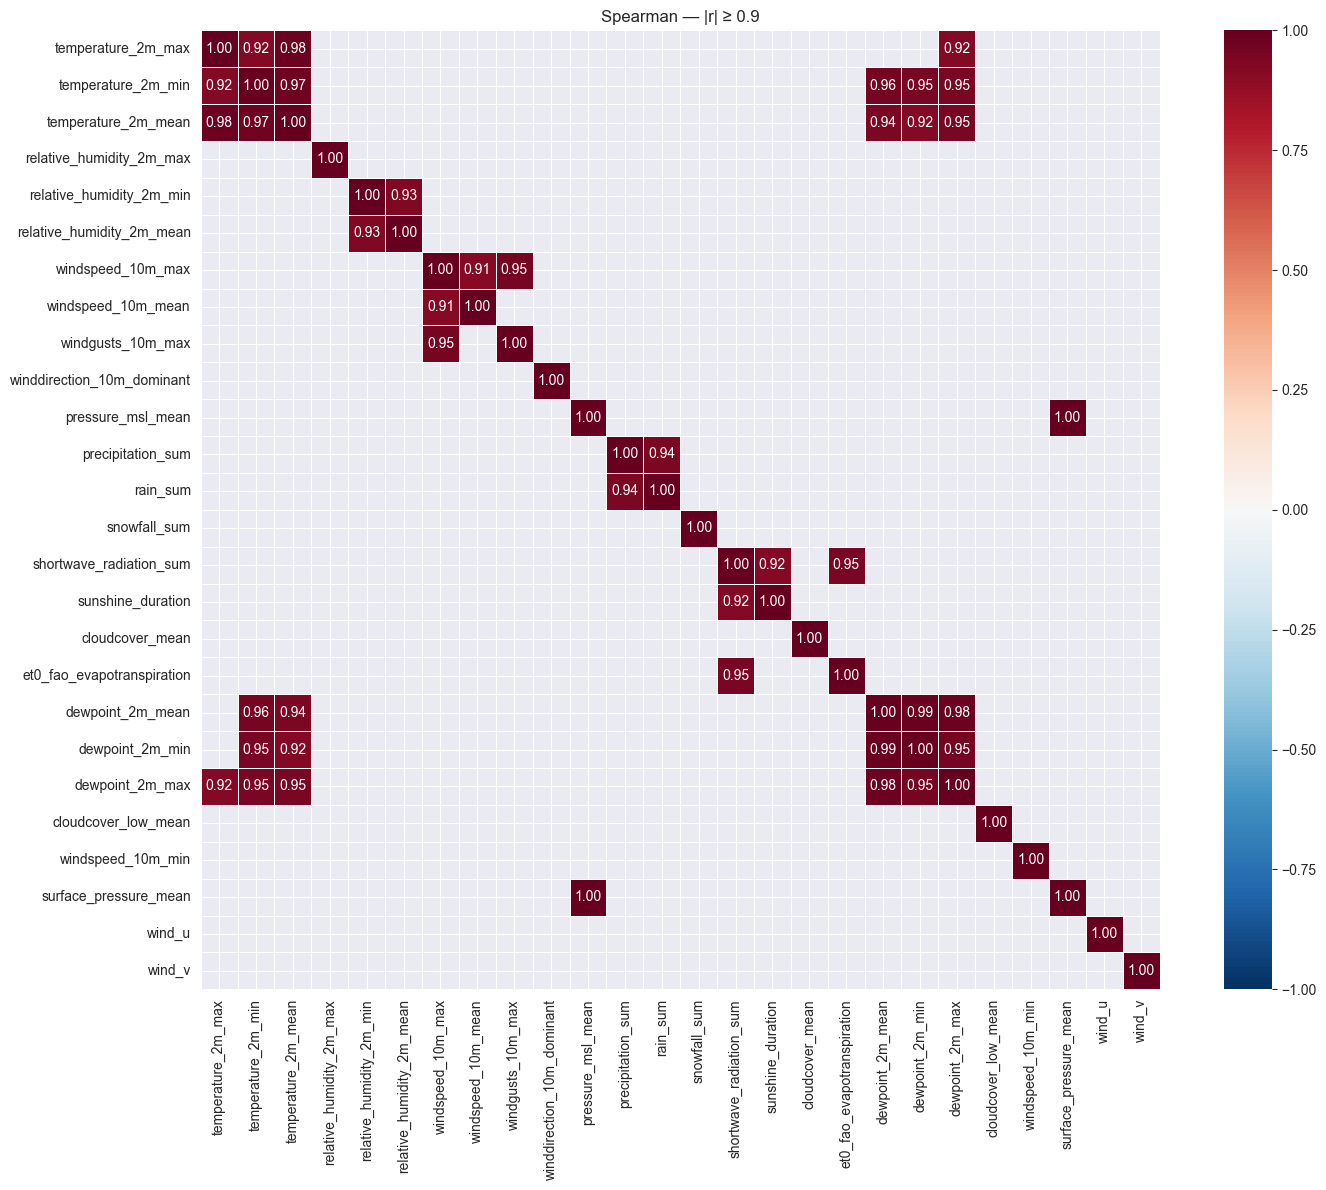

In [53]:
# r_df_p = df.corr(method='pearson')
r_df_s = df.corr(method='spearman')

fig, axes = plt.subplots(1, 1, figsize=(15, 12))


sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() < 0.9,
            square=True, linewidths=0.5,
            ax=axes)
axes.set_title('Spearman — |r| ≥ 0.9') 

plt.tight_layout()
plt.show()

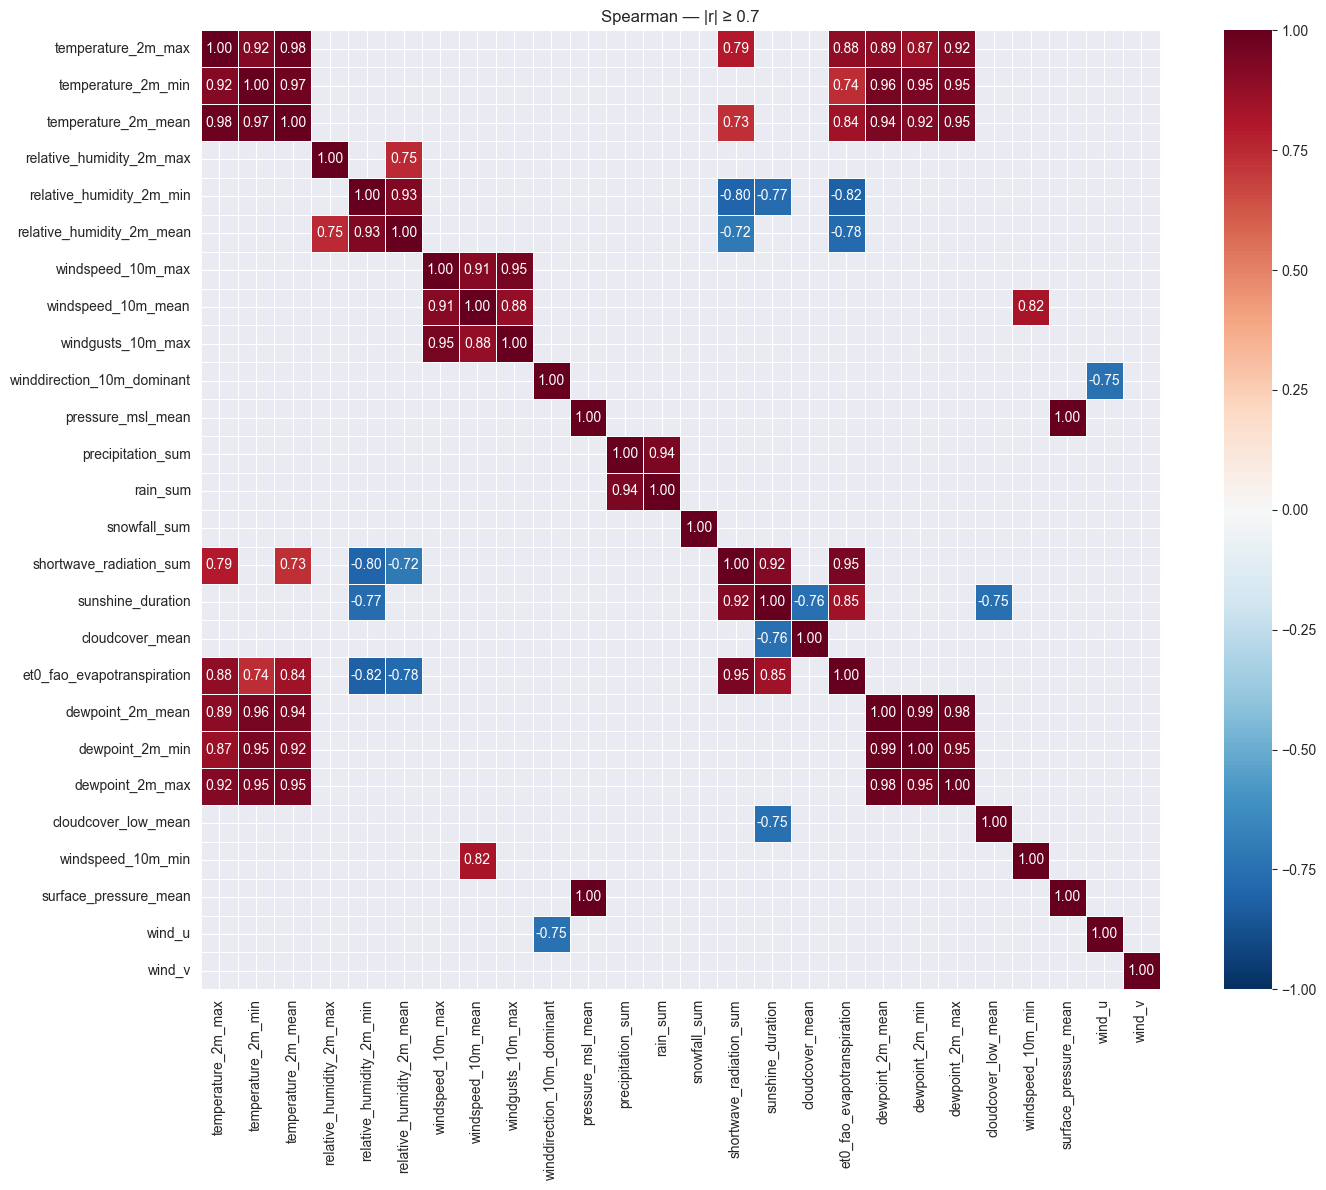

In [54]:
# r_df_p = df.corr(method='pearson')
r_df_s = df.corr(method='spearman')

fig, axes = plt.subplots(1, 1, figsize=(15, 12))


sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() < 0.7,
            square=True, linewidths=0.5,
            ax=axes)
axes.set_title('Spearman — |r| ≥ 0.7') 

plt.tight_layout()
plt.show()

In [55]:
final_vars = ["temperature_2m_mean",      # temperature_2m_max, temperature_2m_min, dewpoint_2m_mean, dewpoint_2m_max, dewpoint_2m_min
              "relative_humidity_2m_mean",  # relative_humidity_2m_max, relative_humidity_2m_min
              # "windspeed_10m_mean",         # windspeed_10m_max
              # "windgusts_10m_max",   # ZASTANOWIC SIE BO SKORELOWANE Z WINDSPEED_10m_mean
              # "winddirection_10m_dominant", # MOZE BYC PROBLEM BO TO KĄT
              "pressure_msl_mean",          # surface_pressure_mean
              "precipitation_sum",          # rain_sum
              "snowfall_sum",  # NIE WIEM CZY WYWALIC OPADY SNIEGU SKORO TO GLOWNIE ZERA
              "shortwave_radiation_sum",    # sunshine_duration_sum, et0_fao_evapotranspiration
              "cloudcover_mean",                   
              # "cloudcover_low_mean"
              'wind_u',  
              'wind_v'] 
              # # ewentualnie dodac u_wind i v_wind

**VIF Interpretation**
- VIF ≈ 1: No correlation with other predictors
- 1 < VIF ≤ 5: Mild to moderate correlation (usually fine)
- VIF > 10: Strong multicollinearity -> take corrective steps

In [56]:
vif_res(df, final_vars)

,variable,VIF
6,shortwave_radiation_sum,5.242432
1,temperature_2m_mean,3.038714
2,relative_humidity_2m_mean,2.251747
7,cloudcover_mean,1.831223
4,precipitation_sum,1.456708
3,pressure_msl_mean,1.443572
9,wind_v,1.385744
5,snowfall_sum,1.199910
8,wind_u,1.182521


In [57]:
df_old = df.copy()
df = df[final_vars]

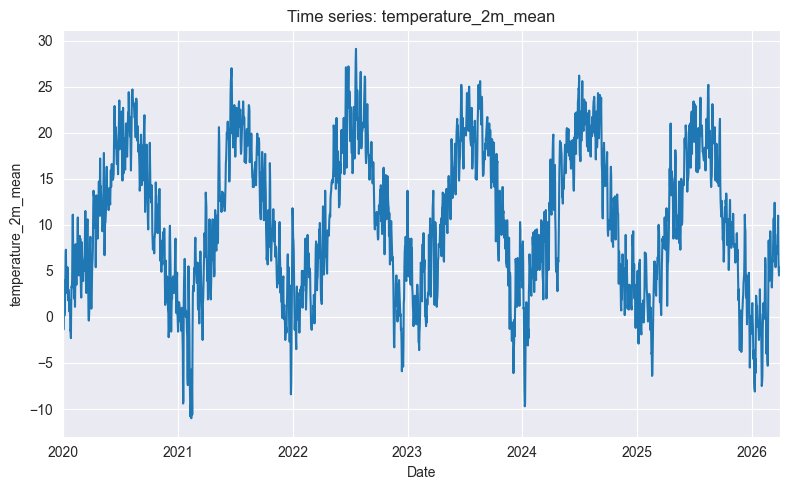

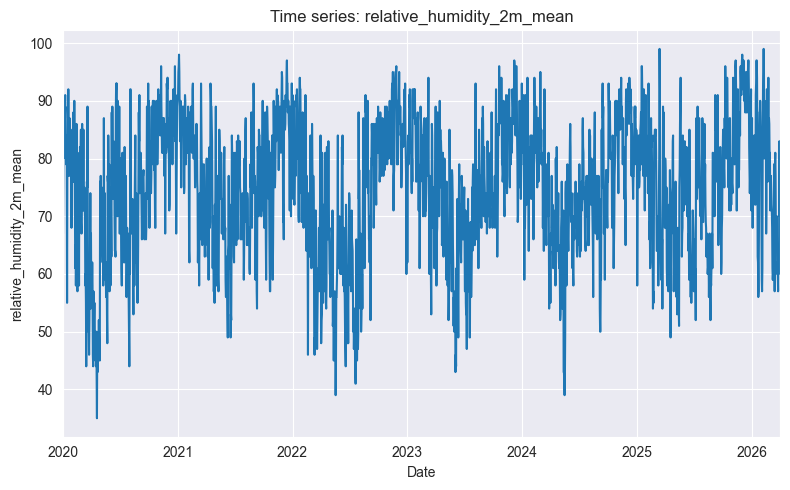

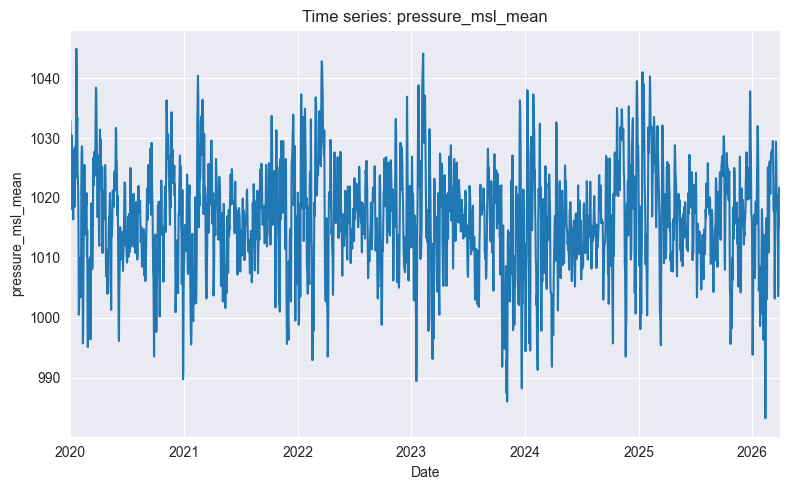

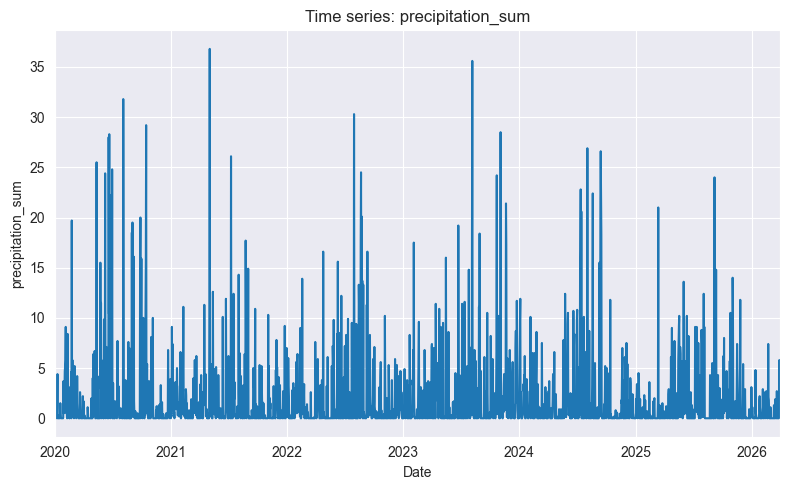

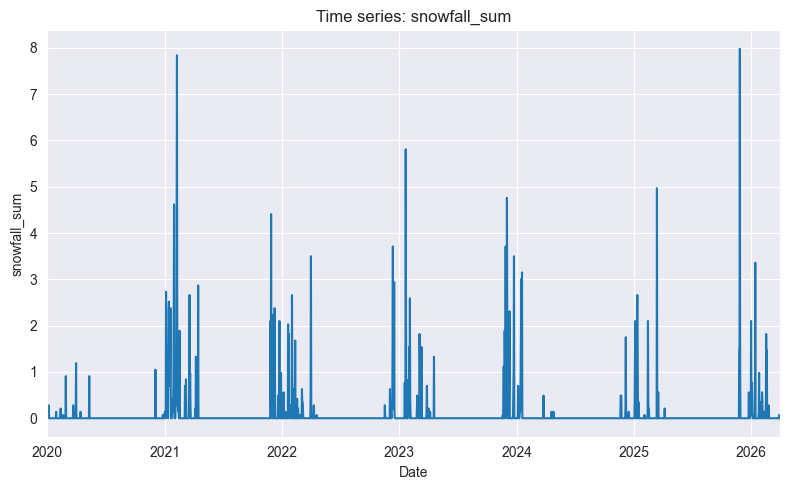

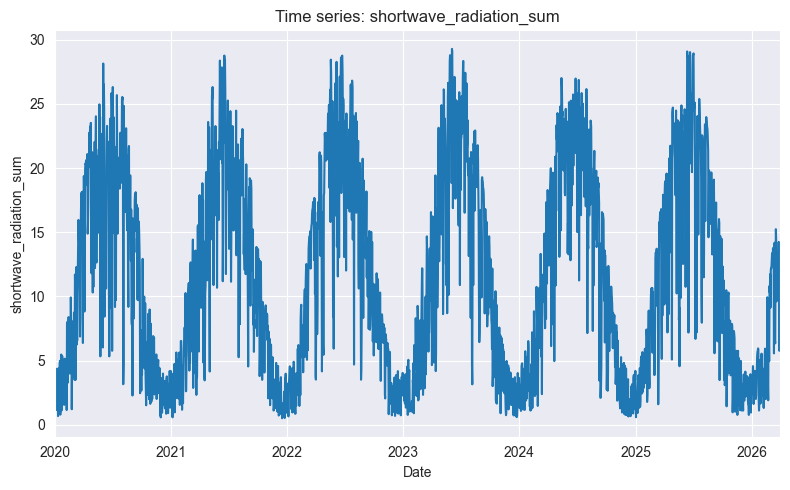

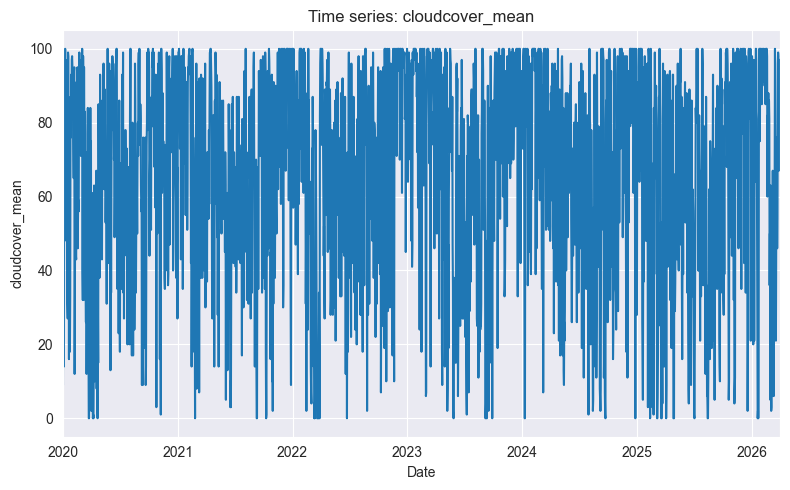

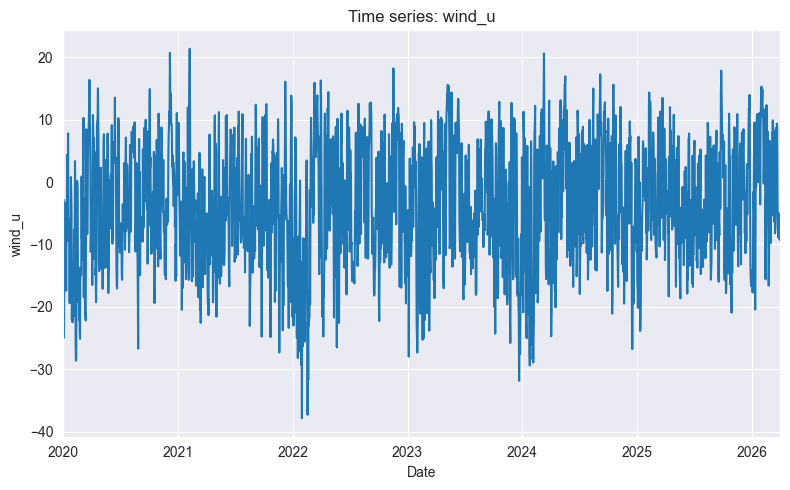

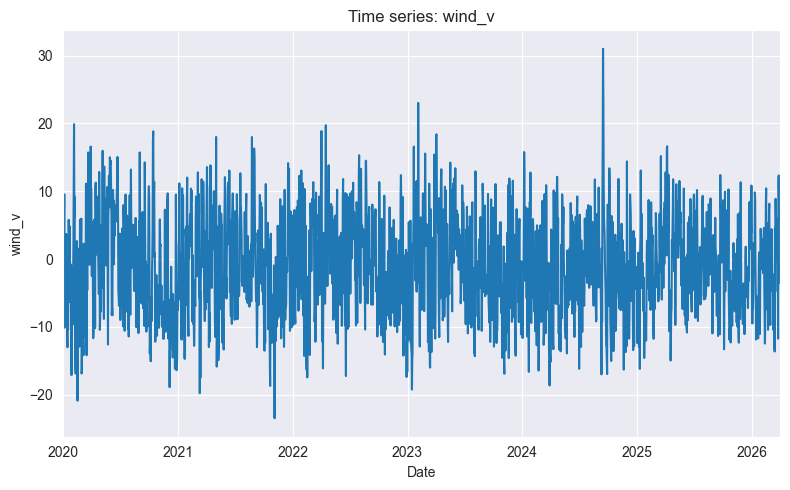

In [58]:
for i, col in enumerate(df.columns):
    df[col].plot(title=f'Time series: {col}', figsize=(8,5))
    plt.ylabel(f'{col}')
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

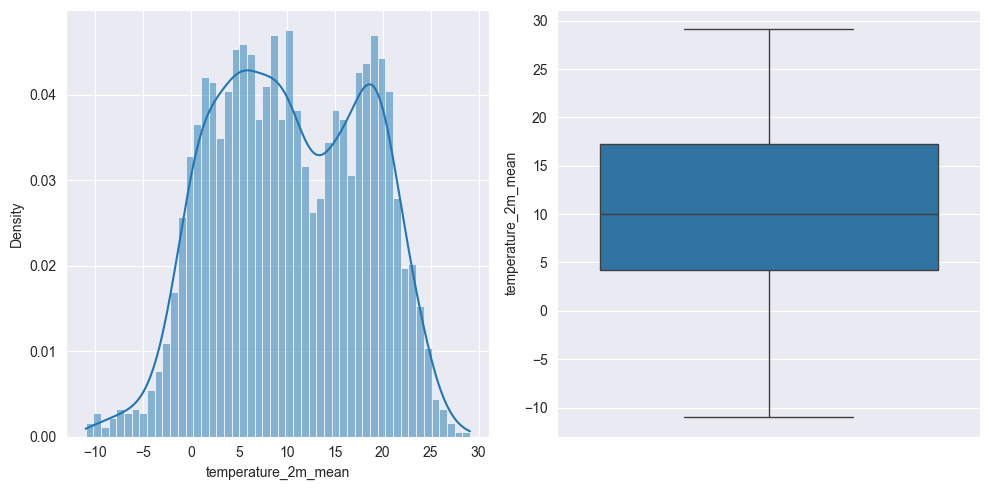

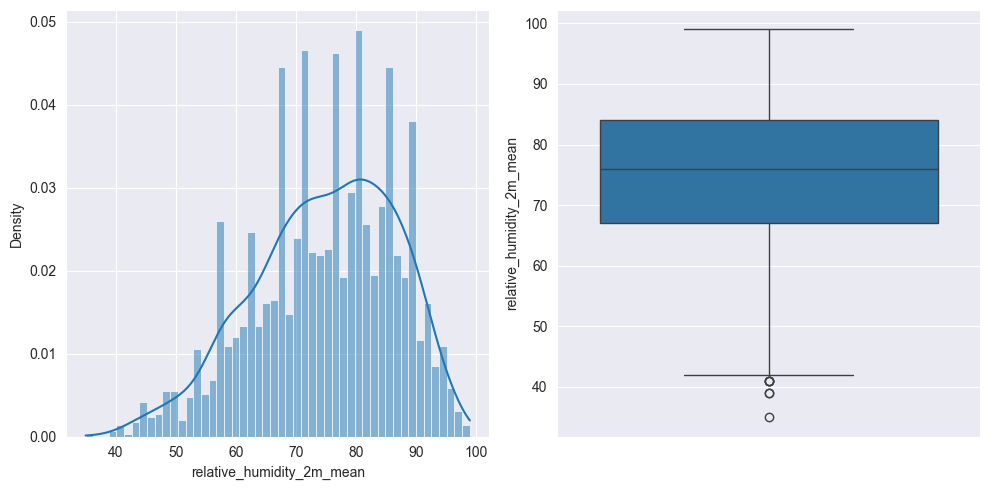

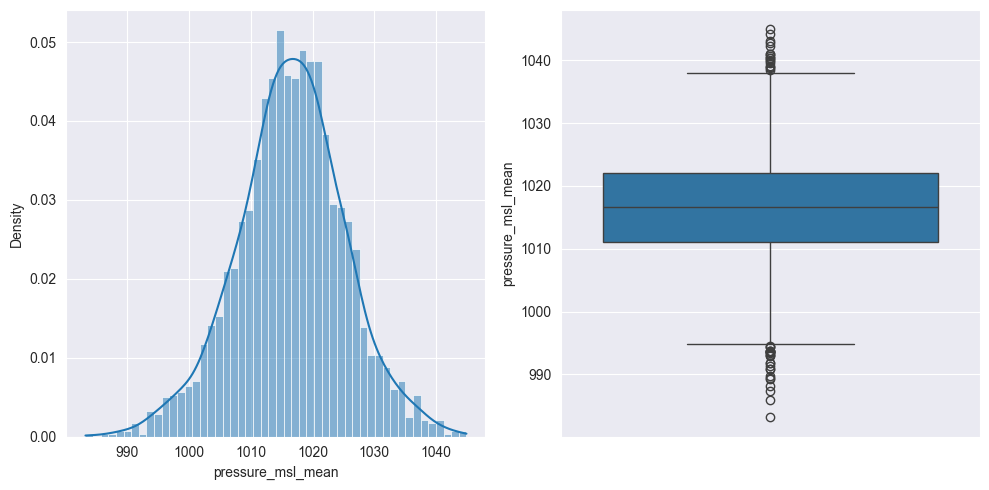

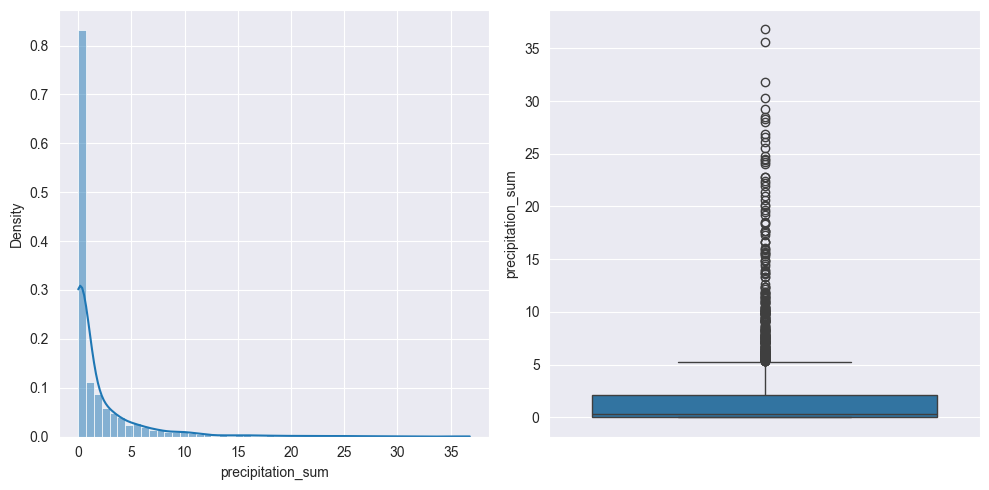

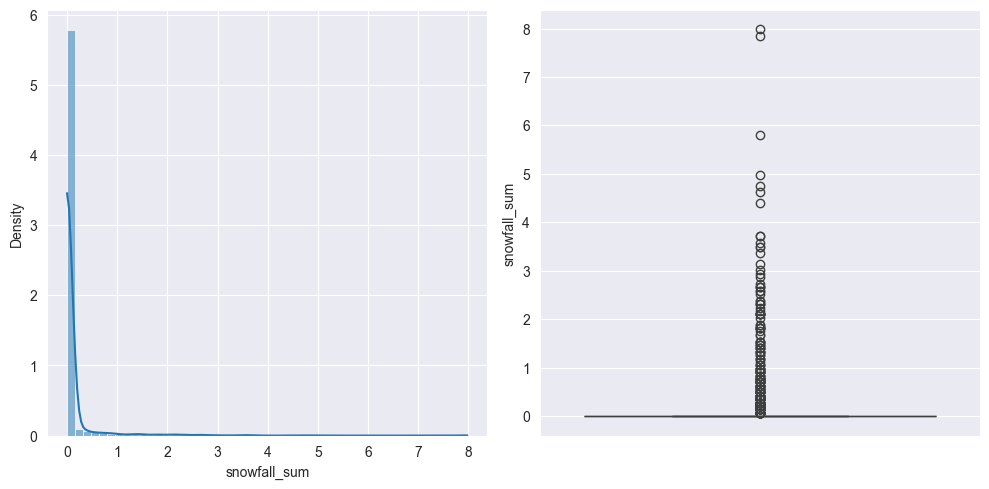

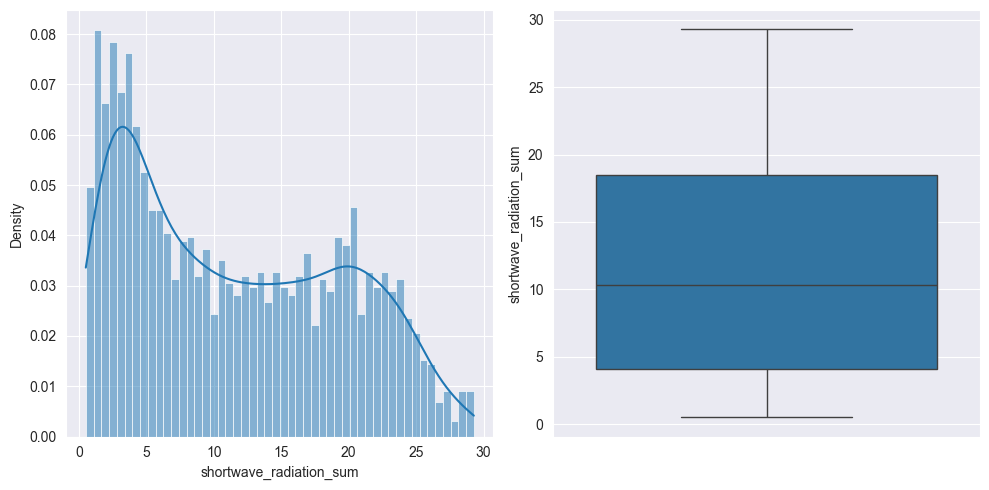

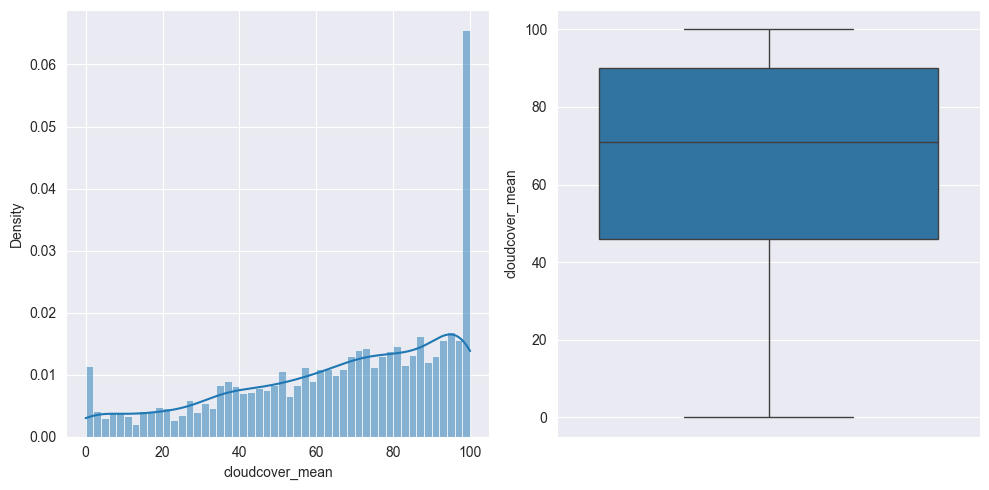

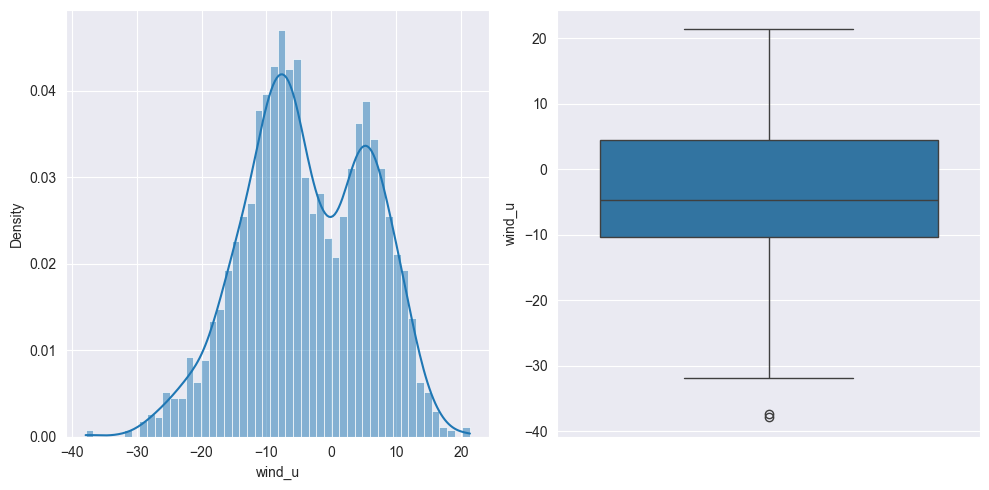

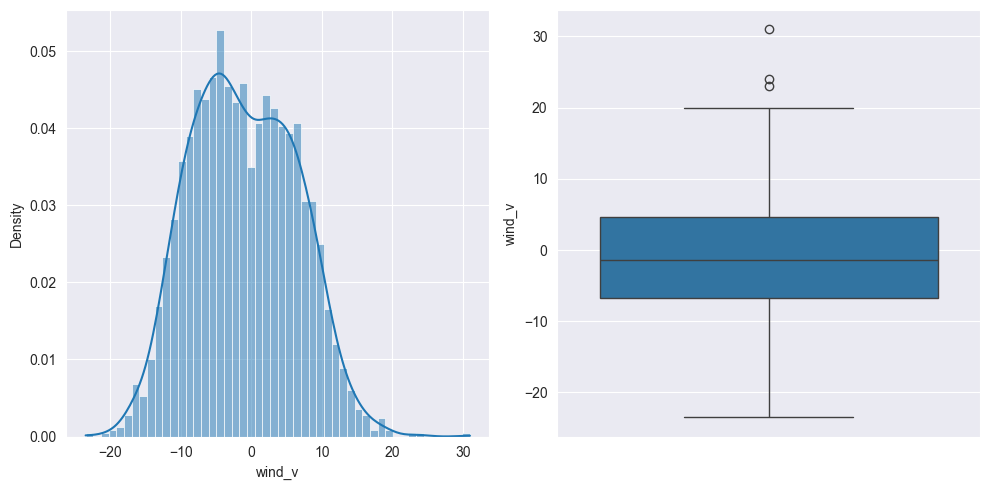

In [59]:
for i, col in enumerate(df.columns):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    sns.boxplot(data=df, y=col, ax=axes[1])
    sns.histplot(data=df, x=col, ax=axes[0], kde=True, bins=50, stat='density')
    plt.tight_layout()
    plt.show()

In [60]:
df['Year'] = df.index.year
df['Month'] = df.index.month_name()
df['DayOfWeek'] = df.index.day_name()

In [61]:
num_cols = df.select_dtypes(include=['float64']).columns.tolist()
num_cols

['temperature_2m_mean',
 'pressure_msl_mean',
 'precipitation_sum',
 'snowfall_sum',
 'shortwave_radiation_sum',
 'wind_u',
 'wind_v']

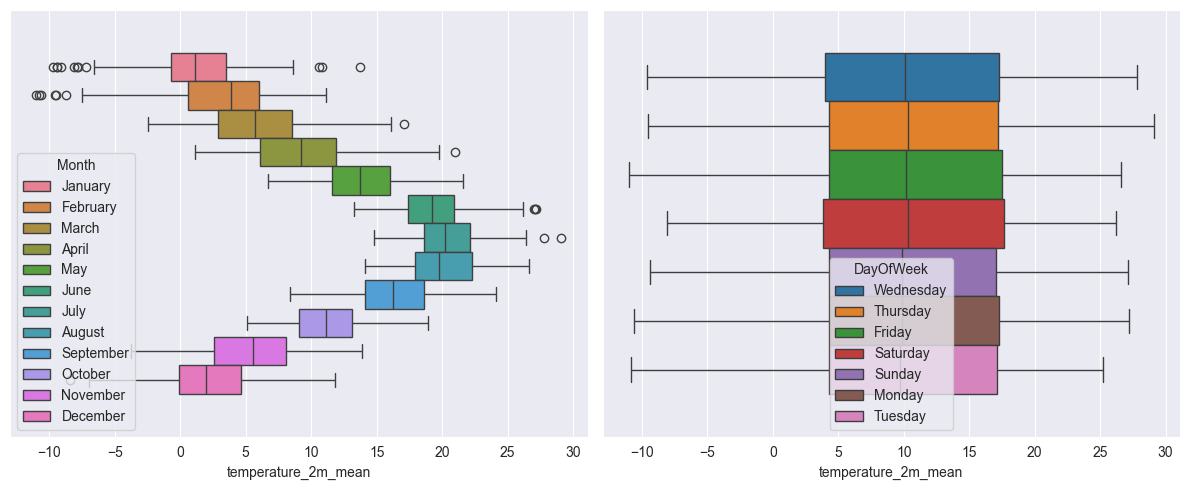

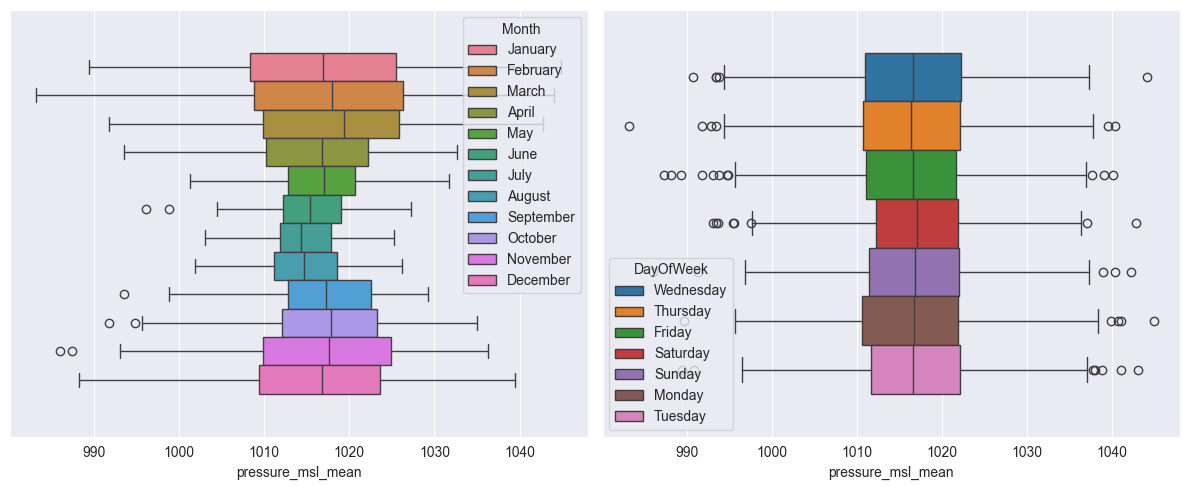

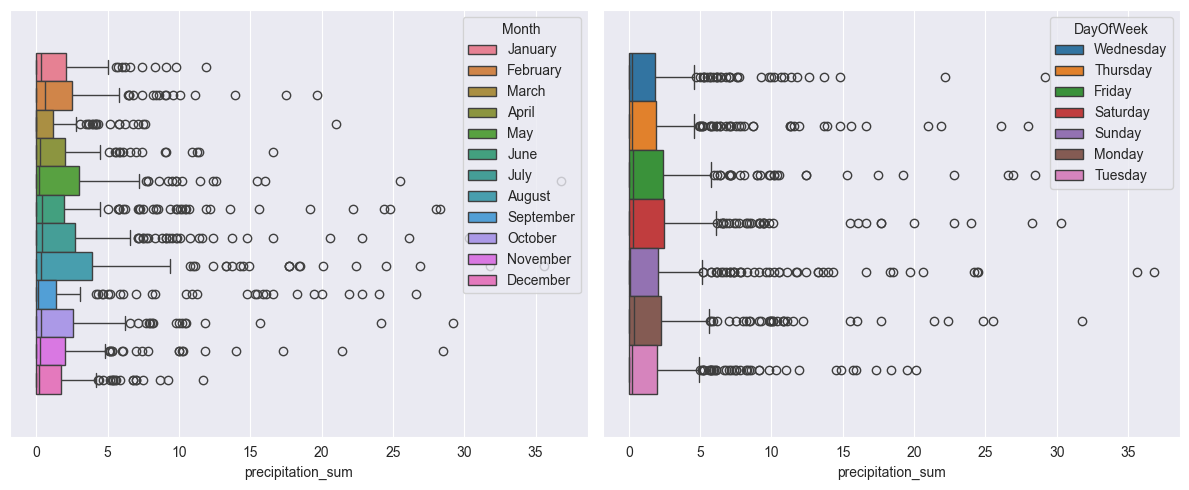

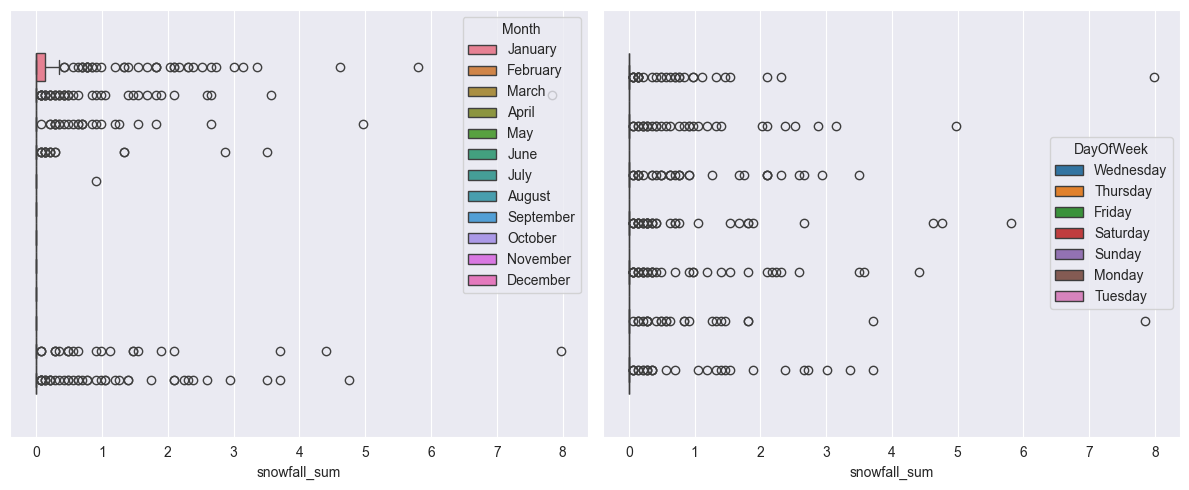

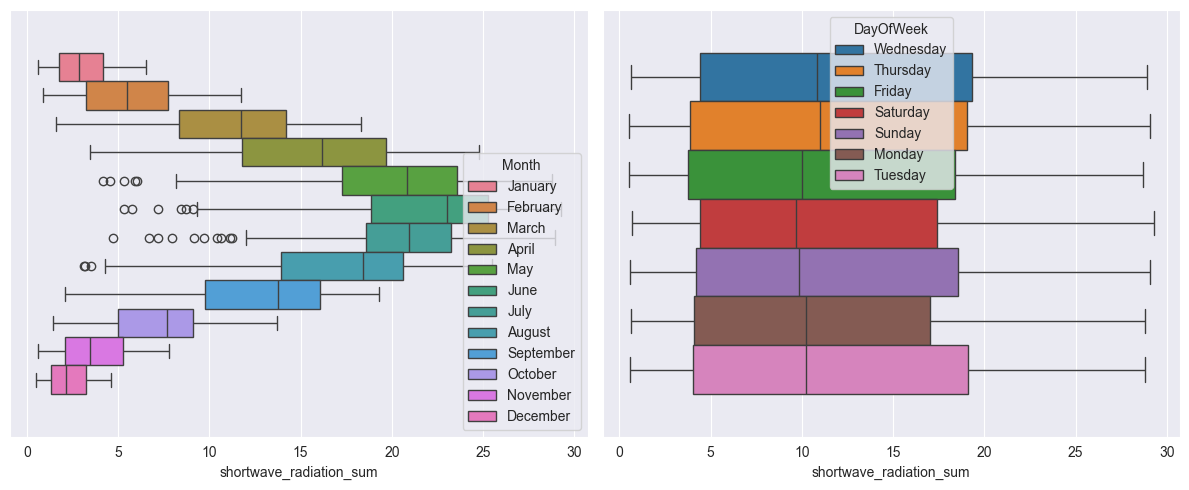

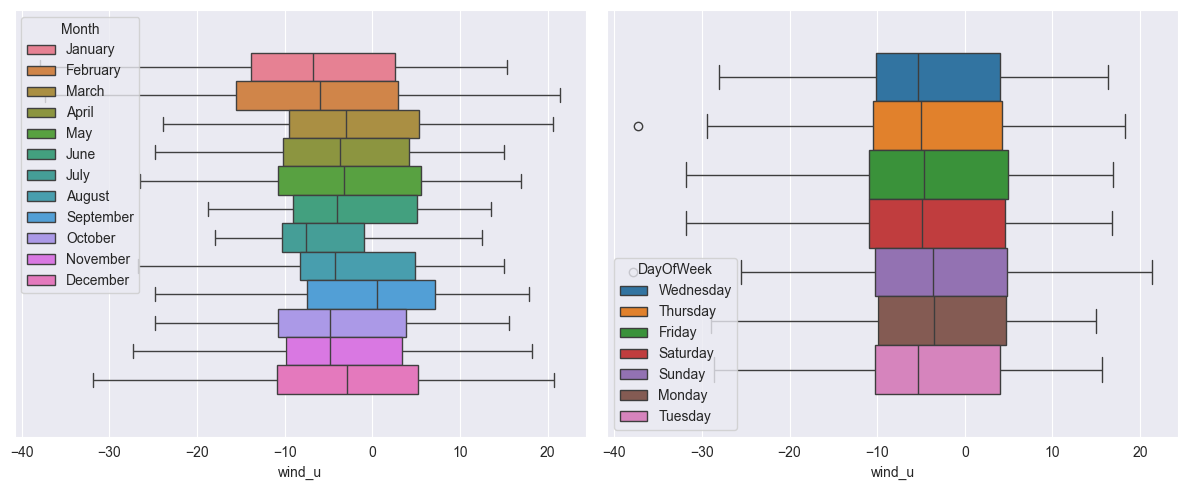

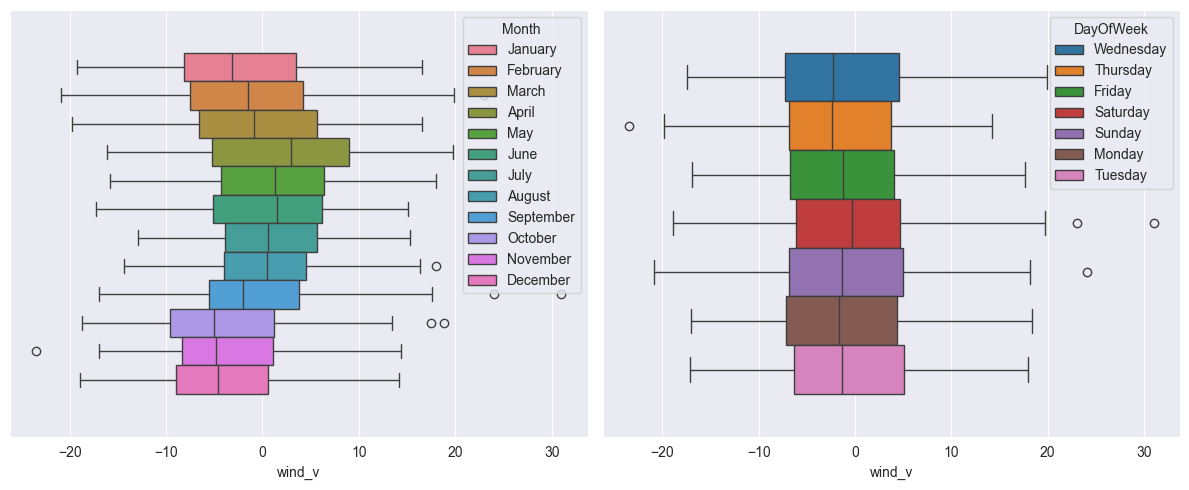

In [62]:
for i, col in enumerate(num_cols):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.boxplot(data=df, x=col, hue=df['Month'], ax=axes[0])
    sns.boxplot(data=df, x=col, hue=df['DayOfWeek'], ax=axes[1])
    plt.xlabel(f'{col}')
    # plt.ylabel('Month')
    plt.tight_layout()
    plt.show()

In [63]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df['Month']     = pd.Categorical(df['Month'],     categories=month_order, ordered=True)
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order,   ordered=True)

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



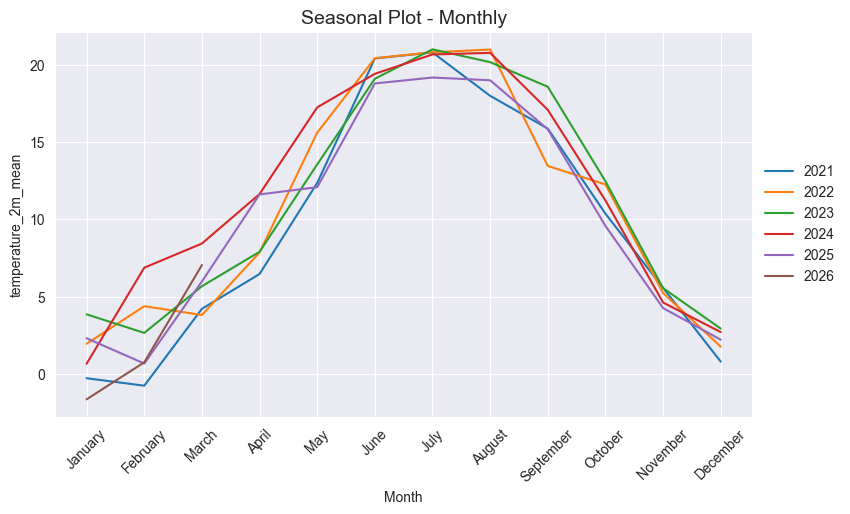

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



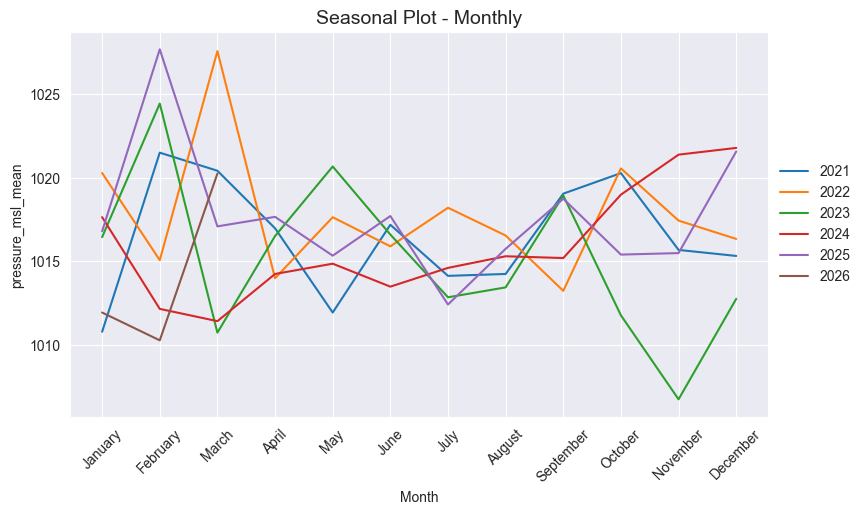

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



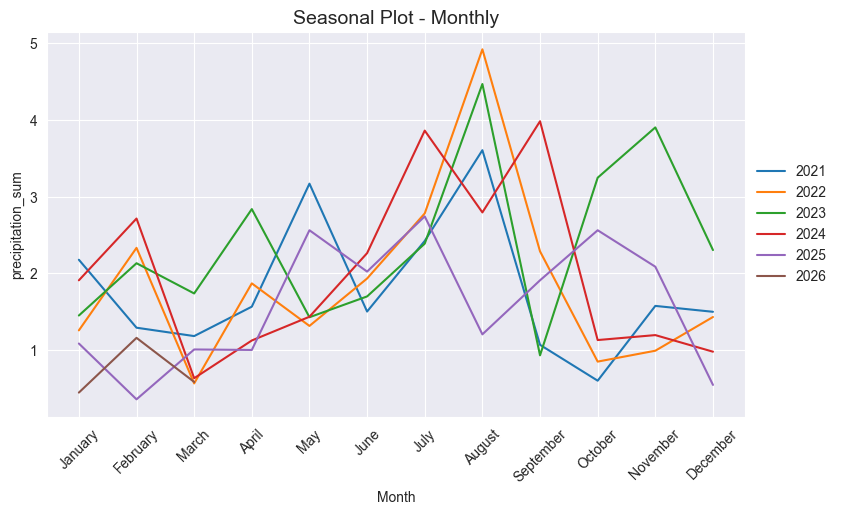

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



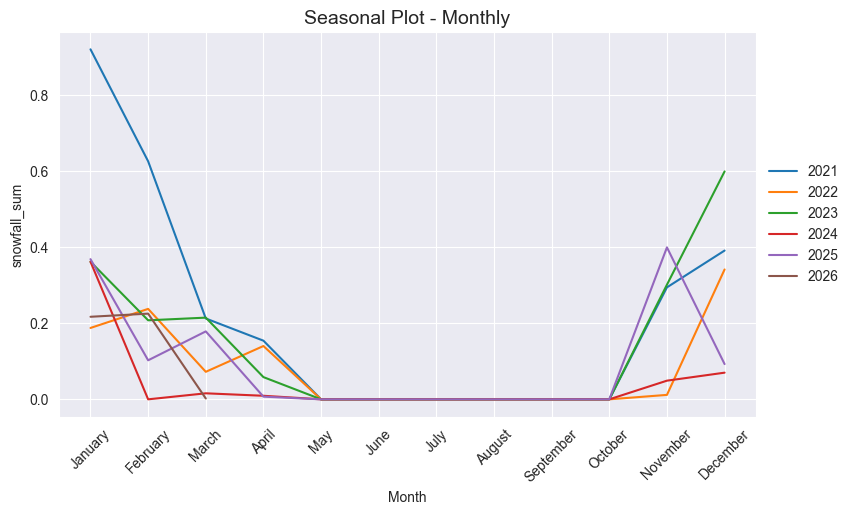

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



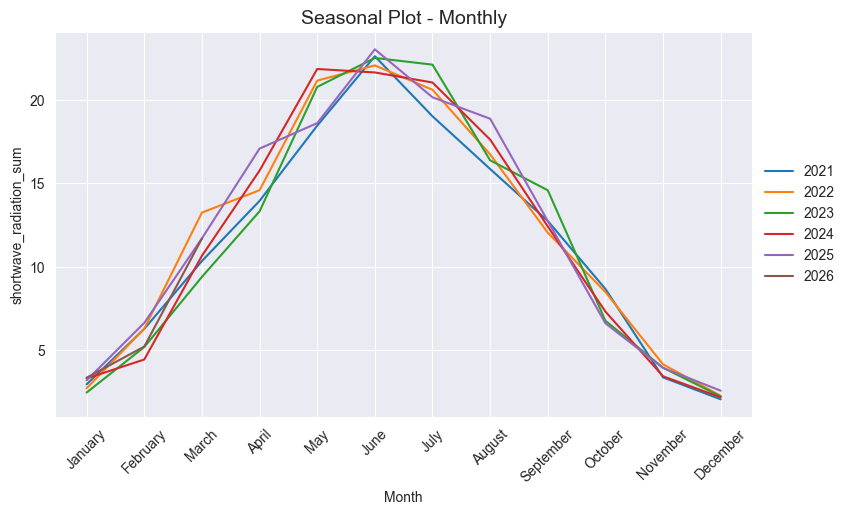

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



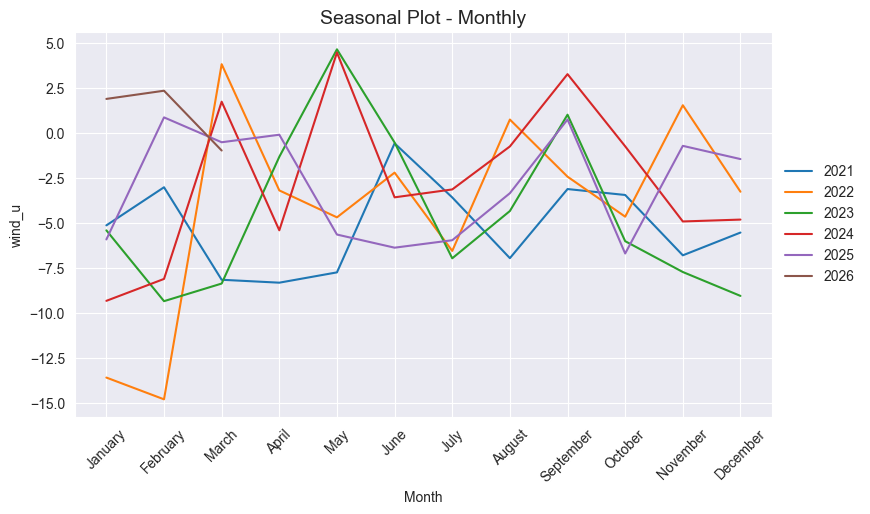

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2796822496.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



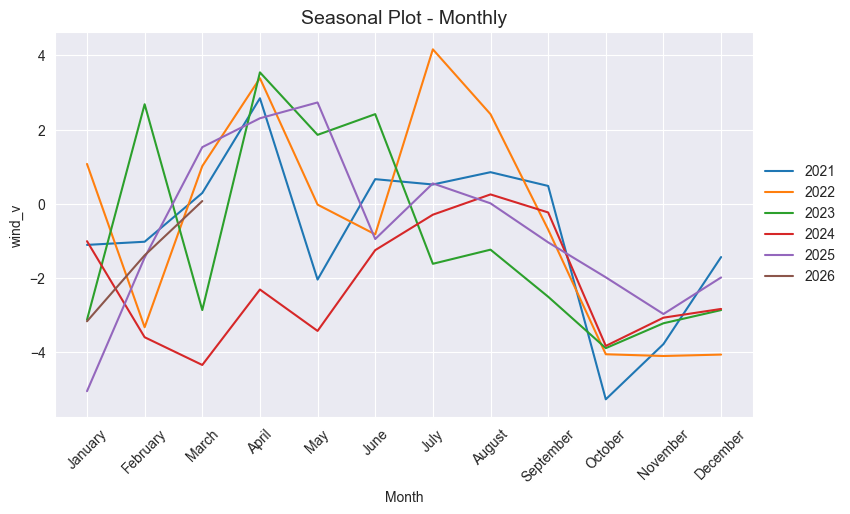

In [64]:
for i, col in enumerate(num_cols):
    df_plot = df[['Month', 'Year', col]].groupby(['Month', 'Year']).mean()[[col]].reset_index()
    years = df_plot['Year'].unique()

    plt.figure(figsize=(9, 5))
    for i, y in enumerate(years):
        if i > 0:
            plt.plot('Month', col, data=df_plot[df_plot['Year'] == y], label=y)

    plt.gca().set(ylabel=col, xlabel='Month')
    plt.xticks(fontsize=10, rotation=45)
    plt.title("Seasonal Plot - Monthly", fontsize=14)
    plt.ylabel(col)
    plt.xlabel('Month')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.show()

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



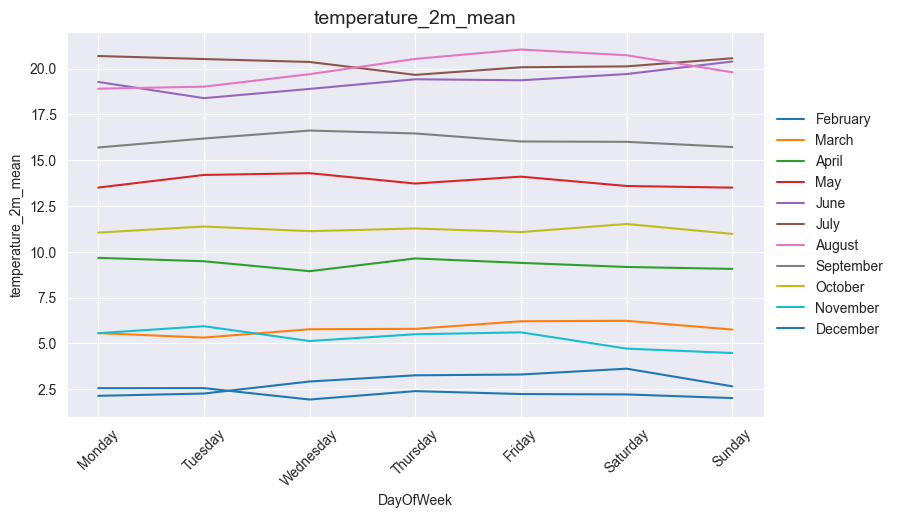

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



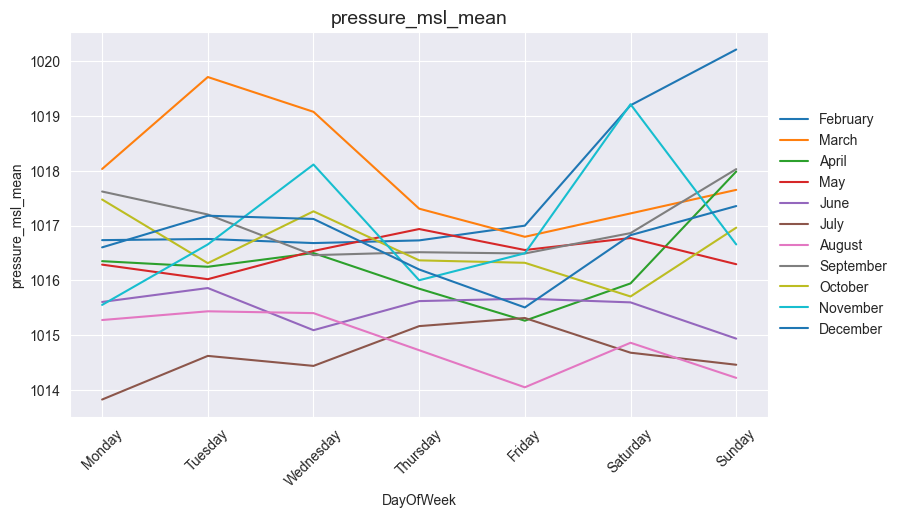

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



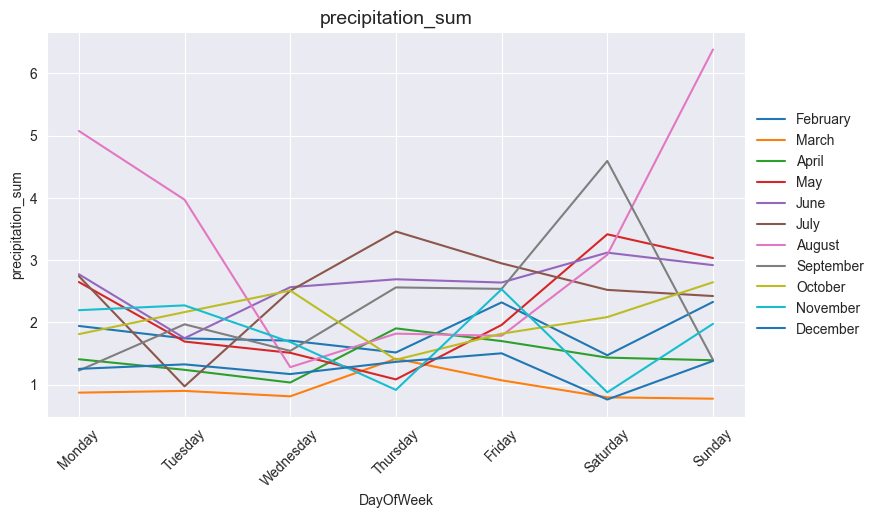

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



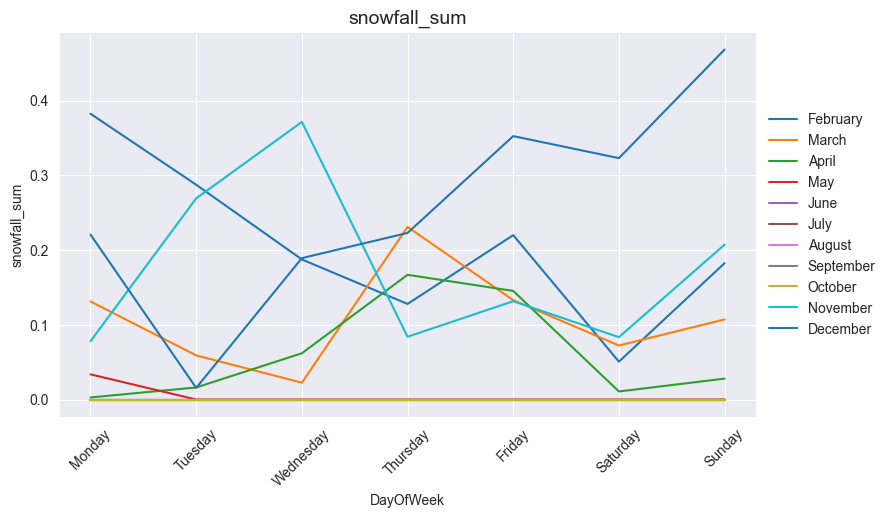

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



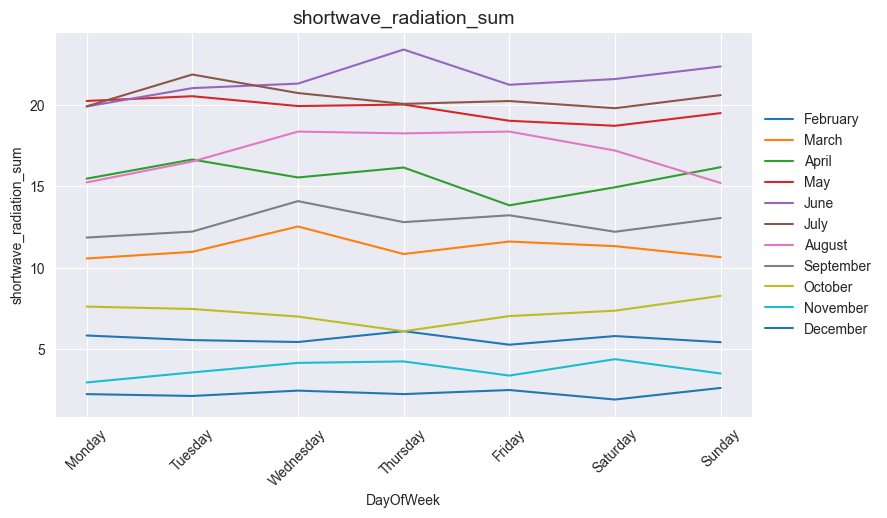

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



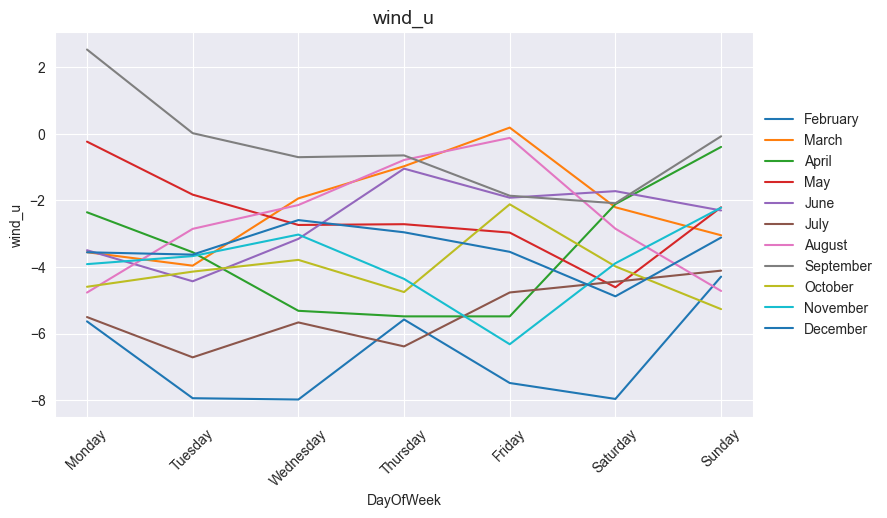

C:\Users\aleks\AppData\Local\Temp\ipykernel_14356\2616150901.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



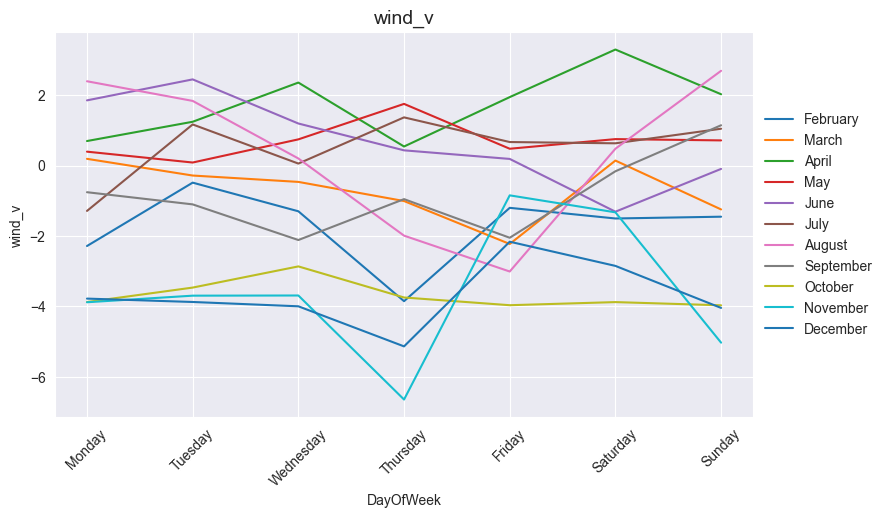

In [65]:
for i, col in enumerate(num_cols):
    df_plot = df[['Month', 'DayOfWeek', col]].groupby(['Month', 'DayOfWeek']).mean()[[col]].reset_index()
    df_plot = df_plot.sort_values(by='DayOfWeek', ascending=True)  

    months = df_plot['Month'].cat.categories  

    plt.figure(figsize=(9, 5))
    for i, m in enumerate(months):
        if i > 0:
            plt.plot('DayOfWeek', col, data=df_plot[df_plot['Month'] == m], label=m)

    plt.gca().set(ylabel=col, xlabel='DayOfWeek')
    plt.xticks(fontsize=10, rotation=45)
    plt.title(f'{col}', fontsize=14)
    plt.xlabel('DayOfWeek')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.show()


In [66]:
df_to_save = df.drop(['Year', 'Month', 'DayOfWeek'], axis=1)

In [67]:
df_to_save.to_csv("./data/cleaned_openmeteo_forecast_daily.csv")